In [2]:
import sys
import pandas as pd
sys.path.append('../lib')
#Note: When working in Windows environments, use:
#sys.path.append('..\lib')
from library import Library
from sample import Sample
import seaborn as sns
color = sns.color_palette()

%matplotlib inline

In [3]:
import urllib.request, json

url = "https://htem-api.nrel.gov/api/sample_library"
response = urllib.request.urlopen(url)
data = json.loads(response.read().decode())

In [4]:
len(data)

1891

In [5]:
all_elements = set()
for entry in data:
    all_elements.update(entry.get("elements", []))
all_elements = sorted(all_elements)

In [6]:
rows = []
for entry in data:
    row = {"id": entry["id"]}
    present_elements = set(entry.get("elements", []))
    
    # Mark 1 if element is in the library, 0 if not
    for element in all_elements:
        row[element] = 1 if element in present_elements else 0
    
    rows.append(row)

In [9]:
df_elements = pd.DataFrame(rows, columns=["id"] + all_elements)
df_elements.sort_values(by="id").reset_index(drop=True)

,id,Ag,Al,Ba,C,Ca,Ce,Co,Cr,Cu,...,Sn,Sr,Ta,Te,Ti,V,W,Y,Zn,Zr
0,2952,0,0,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,1
1,6626,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
2,6628,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,1,0
3,6630,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,6632,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1886,13461,0,0,0,0,0,0,0,0,0,...,0,1,0,0,1,0,0,0,0,0
1887,13462,0,0,0,0,0,0,0,0,0,...,0,1,0,0,1,0,0,0,0,0
1888,13512,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
1889,13513,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


In [11]:
import matplotlib.pyplot as plt

In [12]:
element_counts = df_elements.drop(columns="id").sum()

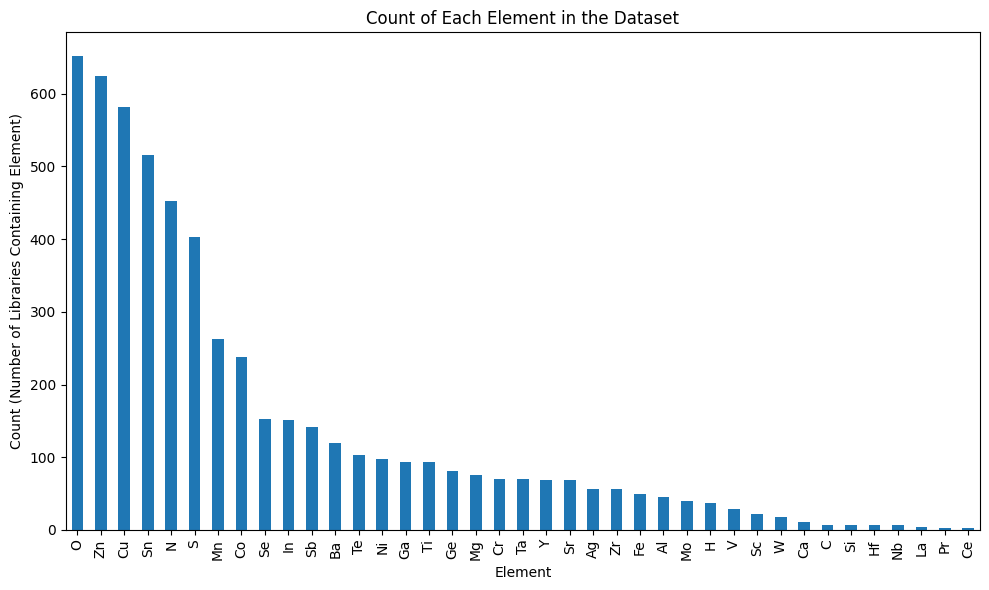

In [15]:
plt.figure(figsize=(10, 6))
element_counts.sort_values(ascending=False).plot(kind="bar")
plt.title("Count of Each Element in the Dataset")
plt.xlabel("Element")
plt.ylabel("Count (Number of Libraries Containing Element)")
plt.tight_layout()
plt.show()

In [16]:
all_elements = sorted(set(df_elements.columns) - {"id"})

In [17]:
import itertools

In [19]:
binary_counts = {}

In [20]:
# Iterate over all unique pairs of elements
for el1, el2 in itertools.combinations(all_elements, 2):
    # Count how many libraries contain BOTH elements (both are 1)
    count = ((df_elements[el1] == 1) & (df_elements[el2] == 1)).sum()
    binary_counts[(el1, el2)] = count

In [21]:
binary_df = pd.DataFrame(
    [(k[0], k[1], v) for k, v in binary_counts.items()],
    columns=["Element_A", "Element_B", "Count"]
)

In [24]:
print("Top 10 Binary Systems by Count:")
print(binary_df.sort_values(by="Count", ascending=False).head(10))

Top 10 Binary Systems by Count:
    Element_A Element_B  Count
619         O        Zn    380
291        Cu         S    298
568         N        Zn    183
703        Sn        Zn    176
514        Mn         O    143
560         N        Sn    137
611         O        Sn    131
228        Co         O    127
640         S        Sn    126
289        Cu         O    115


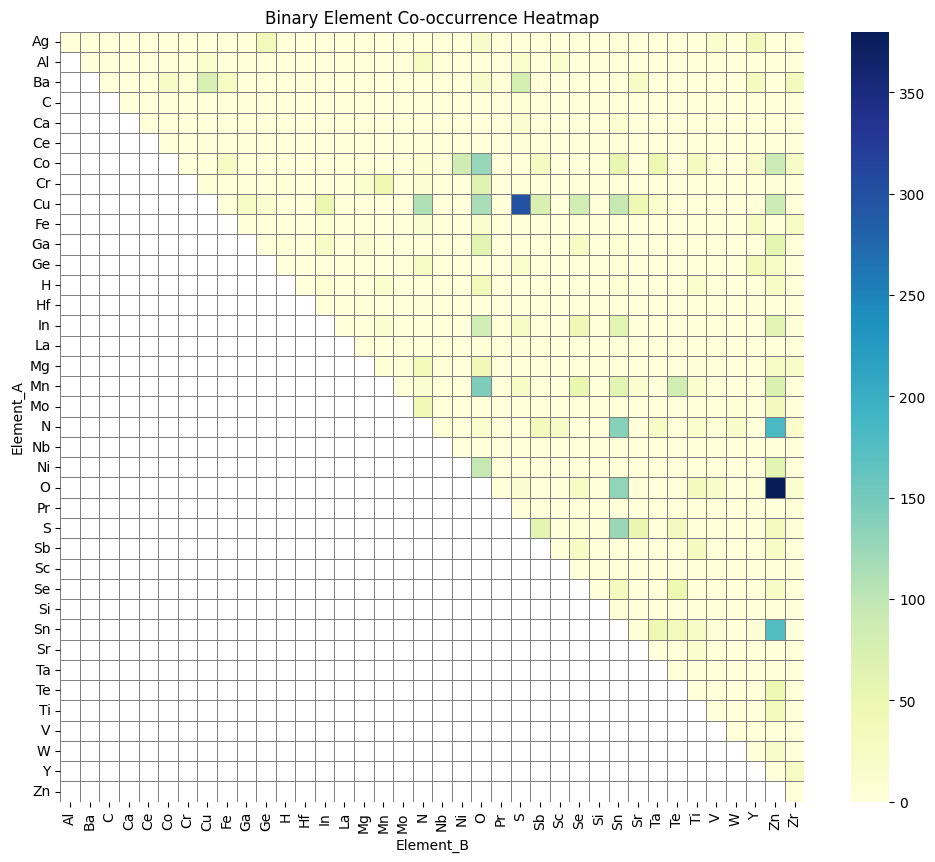

In [26]:
heatmap_data = binary_df.pivot(index="Element_A", columns="Element_B", values="Count")

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_data, cmap="YlGnBu", linewidths=0.5, linecolor='gray')
plt.title("Binary Element Co-occurrence Heatmap")
plt.show()

# As seen with the original bar plot: oxygen, zinc, copper, tin, and cobalt pair the most

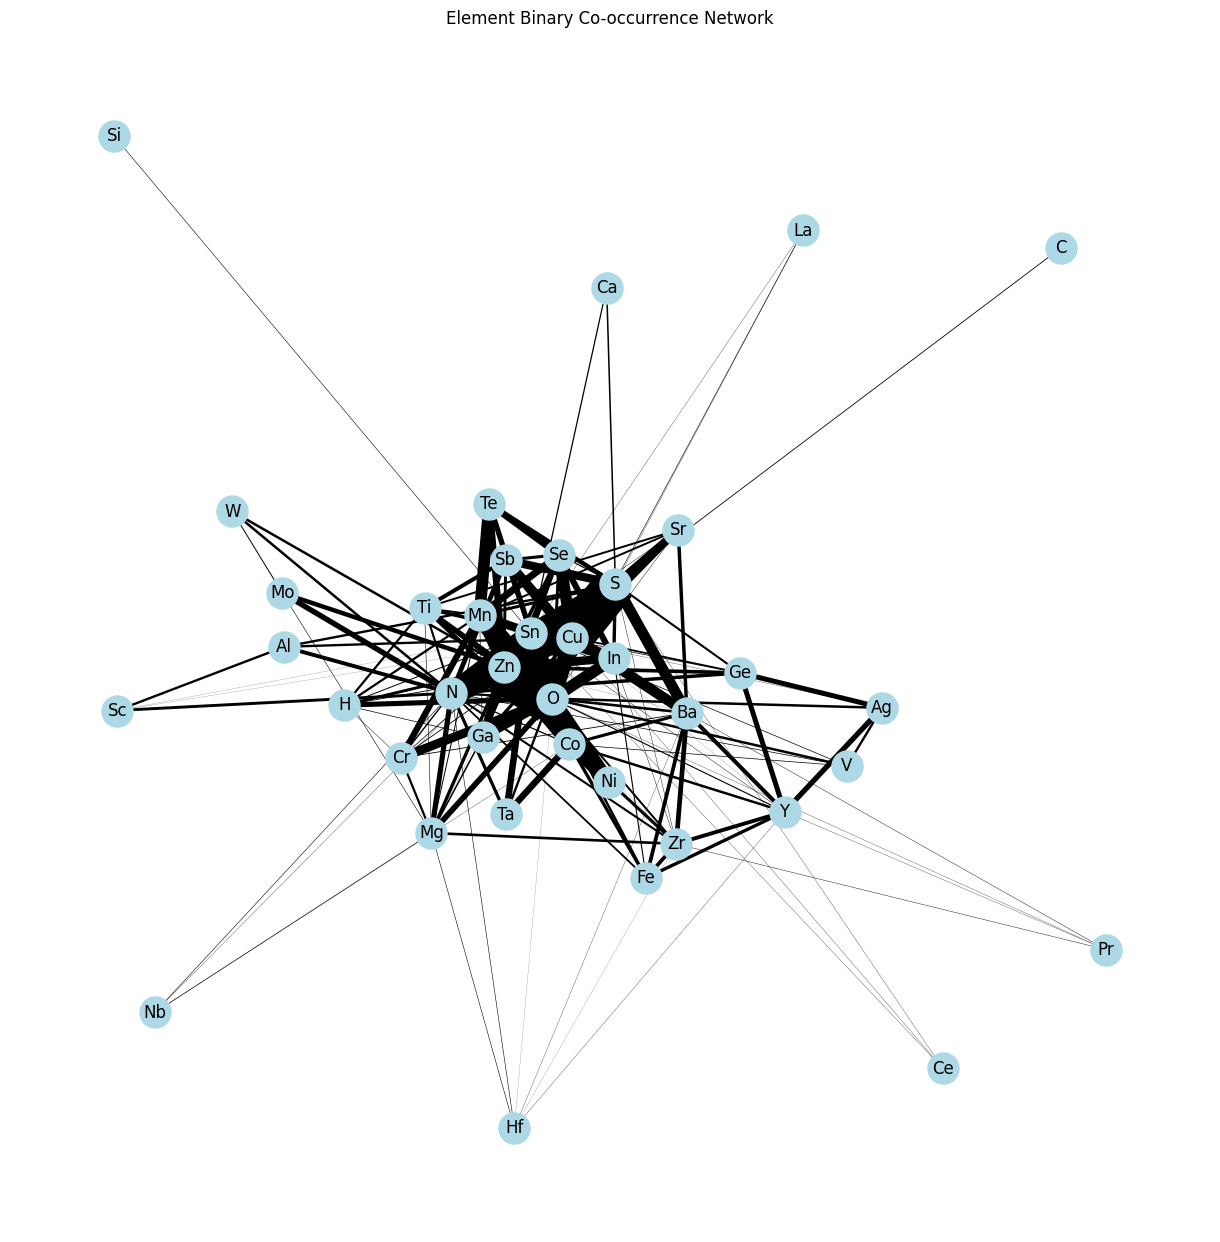

In [31]:
import networkx as nx

# Create graph
G = nx.Graph()

# Add edges with weight = count
for _, row in binary_df.iterrows():
    if row["Count"] > 0:  # Optionally filter low counts
        G.add_edge(row["Element_A"], row["Element_B"], weight=row["Count"])

# Draw the graph
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G, k=0.5)  # Position nodes using force-directed layout
weights = [G[u][v]['weight'] for u,v in G.edges()]
nx.draw(G, pos, with_labels=True, width=[w*0.1 for w in weights], node_size=500, node_color="lightblue")
plt.title("Element Binary Co-occurrence Network")
plt.show()

In [33]:
# top_pairs = binary_df.sort_values(by="Count", ascending=False).head(15)

# plt.figure(figsize=(10, 6))
# plt.barh(
#     y=top_pairs.apply(lambda r: f"{r['Element_A']} & {r['Element_B']}", axis=1), 
#     width=top_pairs["Count"]
# )
# plt.xlabel("Co-occurrence Count")
# plt.title("Top 15 Binary Element Pairs by Co-occurrence")
# plt.gca().invert_yaxis()  # Highest on top
# plt.tight_layout()
# plt.show()

In [27]:
# Repeat for three elements
tertiary_counts = {}

# Iterate over all unique triplets of elements
for el1, el2, el3 in itertools.combinations(all_elements, 3):
    # Count how many libraries contain ALL THREE elements
    count = ((df_elements[el1] == 1) & (df_elements[el2] == 1) & (df_elements[el3] == 1)).sum()
    tertiary_counts[(el1, el2, el3)] = count

# Convert to DataFrame
tertiary_df = pd.DataFrame(
    [(k[0], k[1], k[2], v) for k, v in tertiary_counts.items()],
    columns=["Element_A", "Element_B", "Element_C", "Count"]
)

In [28]:
print("\nTop 10 Tertiary Systems by Count:")
print(tertiary_df.sort_values(by="Count", ascending=False).head(10))


Top 10 Tertiary Systems by Count:
     Element_A Element_B Element_C  Count
4057        Co         O        Zn     88
8541         O        Sn        Zn     88
4026        Co        Ni         O     85
8132         N        Sn        Zn     83
4978        Cu         S        Sn     82
1549        Ba        Cu         S     75
4957        Cu         O        Zn     73
8337        Ni         O        Zn     62
6993        In         O        Zn     61
6985        In         O        Sn     61


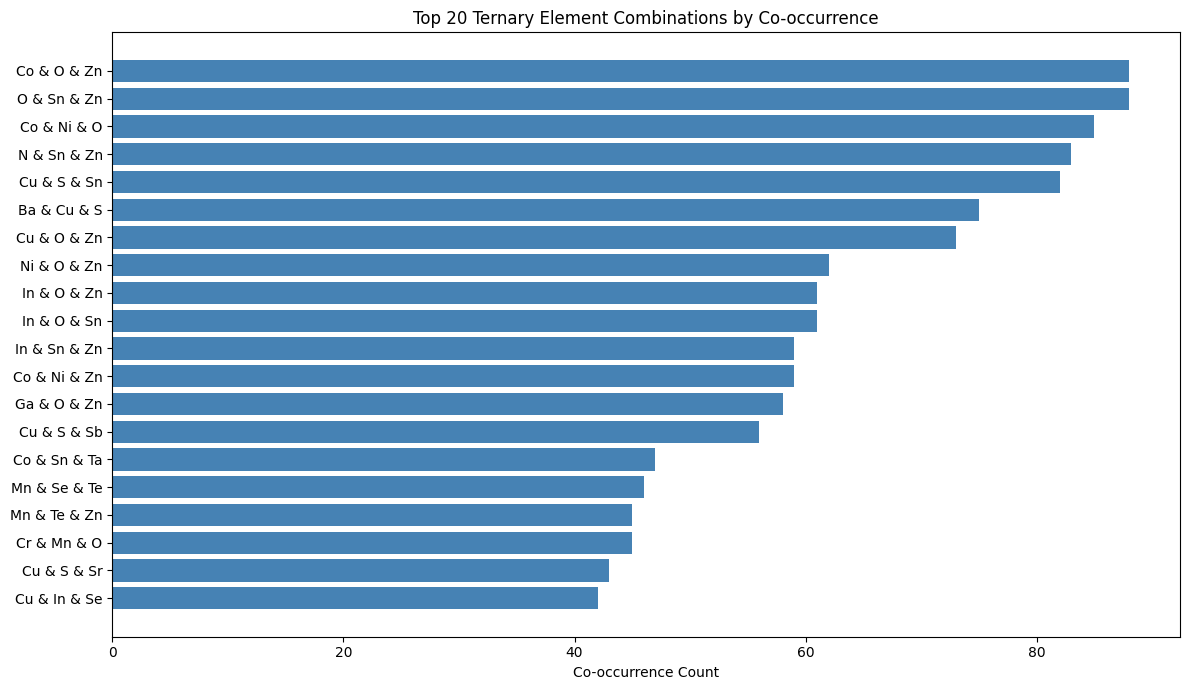

In [35]:
# Three element pairings do not seem to have as drastic of a range as doubles

# Sort and pick top 20 ternary systems by count
top_triplets = tertiary_df.sort_values(by="Count", ascending=False).head(20)

# Create readable labels like "A & B & C"
labels = top_triplets.apply(lambda r: f"{r['Element_A']} & {r['Element_B']} & {r['Element_C']}", axis=1)

plt.figure(figsize=(12, 7))
plt.barh(labels, top_triplets["Count"], color="steelblue")
plt.xlabel("Co-occurrence Count")
plt.title("Top 20 Ternary Element Combinations by Co-occurrence")
plt.gca().invert_yaxis()  # Highest count on top
plt.tight_layout()
plt.show()